In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/multimodal-deepfake/{data,models,src,notebooks,logs}
!ls -la /content/drive/MyDrive/multimodal-deepfake

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total 40
drwx------ 6 root root 4096 Mar  8 20:18 audio_embeddings
drwx------ 6 root root 4096 Mar  8 21:41 audio_embeddings_multiseg
drwx------ 2 root root 4096 Mar  9 19:32 data
drwx------ 2 root root 4096 Mar  8 05:42 logs
drwx------ 2 root root 4096 Mar  9 19:35 models
drwx------ 2 root root 4096 Mar  8 05:42 notebooks
drwx------ 6 root root 4096 Mar  8 06:15 processed
drwx------ 6 root root 4096 Mar  8 06:52 processed_perframe
drwx------ 2 root root 4096 Mar  8 06:00 processed_sample
drwx------ 2 root root 4096 Mar  8 05:42 src


In [1]:
!pip install torch torchvision torchaudio --quiet
!pip install transformers librosa ffmpeg-python opencv-python facenet-pytorch retina-face numpy pandas scikit-learn xgboost tqdm matplotlib soundfile --quiet

In [4]:
import kagglehub
import os

DATA_PATH = kagglehub.dataset_download("nanuradhar/fakeavceleb-v1-2")

print("Dataset path:", DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))

print("Folders inside:")
for f in os.listdir(DATA_PATH):
    print(" -", f)

Dataset path: /Users/jeevikakiran/.cache/kagglehub/datasets/nanuradhar/fakeavceleb-v1-2/versions/1
Dataset exists: True
Folders inside:
 - FakeAVCeleb_v1.2


dataset contents

In [6]:
import shutil

DATA_ROOT = "./FakeAVCeleb_v1.2"

shutil.copytree(DATA_PATH, "./FakeAVCeleb_v1.2", dirs_exist_ok=True)
print("Copied dataset to current directory")

print("DATA_ROOT exists:", os.path.exists(DATA_ROOT))
print("\nTop-level items under dataset root:")
for name in sorted(os.listdir(DATA_ROOT)):
    path = os.path.join(DATA_ROOT, name)
    if os.path.isdir(path):
        children = sorted(os.listdir(path))[:6]
        print(f" - {name}/   (first children: {children})")
    else:
        print(f" - {name}   (file)")

Copied dataset to current directory
DATA_ROOT exists: True

Top-level items under dataset root:
 - FakeAVCeleb_v1.2/   (first children: ['FakeVideo-FakeAudio', 'FakeVideo-RealAudio', 'README.txt', 'RealVideo-FakeAudio', 'RealVideo-RealAudio', 'meta_data.csv'])


## Generating Dataset Metadata

This step scans the FakeAVCeleb dataset directory and automatically generates a metadata file describing each video sample.

The script:
- Detects all category folders inside the dataset root directory.
- Infers **face manipulation labels** and **audio manipulation labels** based on folder names.
- Creates a structured record for every video in the dataset.

For each video, the following information is stored:
- **video_id** – unique identifier for the video
- **category_folder** – the dataset category folder containing the sample
- **relative_path** – path used to locate the video inside the dataset
- **face_label** – whether the visual content is `real` or `fake`
- **audio_label** – whether the audio is `real` or `fake`

All metadata entries are saved into a CSV file:
./fakeavceleb_metadata.csv


This metadata file is later used to:
- organize dataset samples
- assign labels during preprocessing
- build balanced training datasets
- support frame extraction and model training pipelines

In [7]:

import pandas as pd

OUT_CSV = "./fakeavceleb_metadata.csv"

if not os.path.exists(DATA_ROOT):
    raise SystemExit(f"DATA_ROOT not found: {DATA_ROOT}")

categories = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d)) and not d.startswith('.')])
print("Detected category folders:", categories)

rows = []
for cat in categories:
    cat_path = os.path.join(DATA_ROOT, cat)
    # determine labels from folder name (simple)
    cat_low = cat.lower()
    face_label = "fake" if "fakevideo" in cat_low.replace(" ", "") or "fakevideo" in cat_low else ("fake" if "fake" in cat_low and "video" in cat_low else "real")
    audio_label = "fake" if "fakeaudio" in cat_low.replace(" ", "") or "fakeaudio" in cat_low else ("fake" if "fake" in cat_low and "audio" in cat_low else "real")
    # fallback simpler:
    if "fakevideo" in cat_low.replace(" ", "") or cat_low.startswith("fakevideo") or "fakevideo" in cat_low:
        face_label = "fake"
    if "fakeaudio" in cat_low.replace(" ", "") or cat_low.startswith("fakeaudio") or "fakeaudio" in cat_low:
        audio_label = "fake"
    # iterate samples
    for sample in sorted(os.listdir(cat_path)):
        if sample.startswith("."):
            continue
        rows.append({
            "video_id": sample,
            "category_folder": cat,
            "relative_path": sample,
            "face_label": face_label,
            "audio_label": audio_label
        })

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
df.to_csv(OUT_CSV, index=False)
print(f"Metadata written to: {OUT_CSV}  (samples: {len(df)})")
display(df.head(10))

Detected category folders: ['FakeAVCeleb_v1.2']
Metadata written to: ./fakeavceleb_metadata.csv  (samples: 6)


,video_id,category_folder,relative_path,face_label,audio_label
0,FakeVideo-FakeAudio,FakeAVCeleb_v1.2,FakeVideo-FakeAudio,real,real
1,FakeVideo-RealAudio,FakeAVCeleb_v1.2,FakeVideo-RealAudio,real,real
2,README.txt,FakeAVCeleb_v1.2,README.txt,real,real
3,RealVideo-FakeAudio,FakeAVCeleb_v1.2,RealVideo-FakeAudio,real,real
4,RealVideo-RealAudio,FakeAVCeleb_v1.2,RealVideo-RealAudio,real,real
5,meta_data.csv,FakeAVCeleb_v1.2,meta_data.csv,real,real


## Dataset Inspection and Preprocessing Pipeline

This section prepares the **FakeAVCeleb dataset** for training the deepfake detection model.  
The pipeline performs dataset inspection, balancing, frame extraction, duplicate removal, and facial region detection.

### 1. Dataset Exploration
The script first inspects the dataset directory and loads the official metadata file.

Key steps:
- Print all **top-level dataset folders**
- Load the dataset metadata (`meta_data.csv`)
- Inspect available columns and sample rows

This helps verify the dataset structure before processing.


In [25]:
import os

DATA_ROOT = "./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"

print("Top-level folders in dataset:")
for d in os.listdir(DATA_ROOT):
    print("-", d)

Top-level folders in dataset:
- RealVideo-RealAudio
- RealVideo-FakeAudio
- .DS_Store
- FakeVideo-FakeAudio
- FakeVideo-RealAudio
- README.txt
- meta_data.csv


In [27]:
import pandas as pd

META_CSV = os.path.join(DATA_ROOT, "meta_data.csv")
df = pd.read_csv(META_CSV)

print("CSV columns:", df.columns.tolist())
print("First 5 rows:\n", df.head())

CSV columns: ['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path', 'Unnamed: 9']
First 5 rows:
     source target1 target2 method category                 type     race  \
0  id00076       -       -   real        A  RealVideo-RealAudio  African   
1  id00166       -       -   real        A  RealVideo-RealAudio  African   
2  id00173       -       -   real        A  RealVideo-RealAudio  African   
3  id00366       -       -   real        A  RealVideo-RealAudio  African   
4  id00391       -       -   real        A  RealVideo-RealAudio  African   

  gender       path                                         Unnamed: 9  
0    men  00109.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id...  
1    men  00010.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id...  
2    men  00118.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id...  
3    men  00118.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id...  
4    men  00052.mp4  FakeAVCeleb/RealVideo-Real

### 2. Metadata Cleaning and Label Creation
The metadata is cleaned and transformed to create labels for model training.

Operations performed:
- Fix folder paths so they correctly point to the video files.
- Create a **binary label (`REAL` or `FAKE`)** based on the manipulation type.
- Split the dataset into real and fake subsets.
- Build a **balanced dataset** by sampling an equal number of real and fake videos.

Balancing prevents the model from being biased toward one class.

In [44]:
import pandas as pd
import os

DATA_ROOT = "./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"
META_CSV = os.path.join(DATA_ROOT, "meta_data.csv")

df = pd.read_csv(META_CSV)

# Fix folder path
df['folder_path'] = df['Unnamed: 9'].apply(
    lambda x: x[len("FakeAVCeleb/"):] if x.startswith("FakeAVCeleb/") else x
)

# Create REAL / FAKE label
df["video_label"] = df["type"].apply(
    lambda x: "REAL" if "RealVideo" in x else "FAKE"
)

real_df = df[df.video_label == "REAL"]
fake_df = df[df.video_label == "FAKE"]

N = min(len(real_df), len(fake_df))

balanced_df = pd.concat([
    real_df.sample(N, random_state=42),
    fake_df.sample(N, random_state=42)
]).reset_index(drop=True)

print("Balanced dataset size:", len(balanced_df))
print(balanced_df.video_label.value_counts())

Balanced dataset size: 2000
video_label
REAL    1000
FAKE    1000
Name: count, dtype: int64


### 3. Frame Extraction from Videos
Each video is converted into a set of representative frames.

The extraction function:
- Reads the video using **OpenCV**
- Uniformly samples up to **200 frames per video**
- Skips frames that are too similar to previously saved frames
- Saves frames to disk for later processing

This ensures:
- consistent temporal sampling
- reduced redundancy
- manageable dataset size

In [52]:
import cv2
import os
import numpy as np

MAX_FRAMES = 200
DUP_THRESHOLD = 5  # mean pixel difference threshold to consider frames duplicates

def extract_uniform_frames(video_path, out_dir):
    """
    Extracts approximately MAX_FRAMES uniform frames from video_path,
    removing near-duplicate frames.
    Returns list of saved frame paths.
    """
    os.makedirs(out_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return []

    step = max(1, total_frames // MAX_FRAMES)

    saved_paths = []
    prev_frame = None
    frame_idx = 0
    saved_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % step == 0:
            # check near duplicate
            if prev_frame is not None:
                diff = cv2.absdiff(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY),
                                   cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY))
                mean_diff = np.mean(diff)
                if mean_diff < DUP_THRESHOLD:
                    frame_idx += 1
                    continue

            fname = f"frame_{saved_idx:05d}.jpg"
            path = os.path.join(out_dir, fname)
            cv2.imwrite(path, frame)
            saved_paths.append(path)
            saved_idx += 1
            prev_frame = frame

        frame_idx += 1

        if saved_idx >= MAX_FRAMES:
            break

    cap.release()
    return saved_paths

In [46]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 41.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imagehash]


### 4. Removing Near-Duplicate Frames
Even after uniform sampling, consecutive frames may still look nearly identical.

To address this:
- A **perceptual hash (pHash)** is computed for each frame
- Frames with very similar hashes are removed

This keeps only visually distinct frames and improves training efficiency.


In [53]:
from PIL import Image
import imagehash
import os

HASH_THRESHOLD = 5

def remove_duplicate_frames(frame_paths):
    """
    Remove near-duplicate frames using perceptual hashing (phash).
    Keeps first frame, removes subsequent frames that are too similar.
    Returns list of kept frame paths.
    """
    if not frame_paths:
        return []

    kept = [frame_paths[0]]
    try:
        last_hash = imagehash.phash(Image.open(frame_paths[0]))
    except Exception:
        last_hash = None

    for f in frame_paths[1:]:
        try:
            current_hash = imagehash.phash(Image.open(f))
        except Exception:
            continue

        if last_hash is None or abs(last_hash - current_hash) > HASH_THRESHOLD:
            kept.append(f)
            last_hash = current_hash
        else:
            # remove duplicate frame
            try:
                os.remove(f)
            except Exception:
                pass

    return kept

### 5. Face Detection with MTCNN
Deepfake artifacts typically appear in facial regions.  
Therefore, the pipeline detects faces in every extracted frame using **MTCNN**.

For each frame:
- The face bounding box is detected
- Coordinates are saved to a `detections.csv` file
- The first detected face is saved as:
  - `face_crop.jpg` (entire face)
  - `mouth_roi.jpg` (mouth region)

These outputs allow later stages to:
- crop faces consistently
- focus on manipulation artifacts around the mouth

In [55]:
from tqdm import tqdm
from PIL import Image
from facenet_pytorch import MTCNN
import os
import shutil
import traceback

OUT_ROOT = "./processed"
os.makedirs(OUT_ROOT, exist_ok=True)

# Setup MTCNN
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=False, device=device)

errors = []

for idx, row in tqdm(balanced_df.iterrows(), total=len(balanced_df), desc="Samples"):

    try:
        folder = os.path.join(DATA_ROOT, row.folder_path)
        video_path = os.path.join(folder, row.path)

        if not os.path.exists(video_path):
            errors.append((row.source, "video_not_found"))
            continue

        vid = row.source
        label = row.video_label

        out_dir = os.path.join(OUT_ROOT, label, vid)
        frames_dir = os.path.join(out_dir, "frames")
        os.makedirs(frames_dir, exist_ok=True)

        # 1) Extract uniform frames
        frames = extract_uniform_frames(video_path, frames_dir)

        # 2) Remove near-duplicate frames
        frames = remove_duplicate_frames(frames)

        # 3) Run MTCNN and save detections.csv
        detections_csv = os.path.join(out_dir, "detections.csv")
        face_crop_path = os.path.join(out_dir, "face_crop.jpg")
        mouth_path = os.path.join(out_dir, "mouth_roi.jpg")

        with open(detections_csv, "w") as fh:
            fh.write("frame,x1,y1,x2,y2,prob\n")
            first_saved = False
            for fp in frames:
                try:
                    img = Image.open(fp).convert("RGB")
                    boxes, probs = mtcnn.detect(img)
                    if boxes is None or len(boxes) == 0:
                        fh.write(f"{os.path.basename(fp)},,,,0\n")
                        continue

                    x1, y1, x2, y2 = [int(v) for v in boxes[0]]
                    prob = float(probs[0]) if probs is not None else 1.0
                    fh.write(f"{os.path.basename(fp)},{x1},{y1},{x2},{y2},{prob}\n")

                    # save first face + mouth crop for reference
                    if not first_saved:
                        face = img.crop((x1, y1, x2, y2))
                        face.save(face_crop_path)

                        w, h = face.size
                        mx1, my1 = int(0.15 * w), int(0.55 * h)
                        mx2, my2 = int(0.85 * w), int(0.95 * h)
                        mouth = face.crop((mx1, my1, mx2, my2))
                        mouth.save(mouth_path)
                        first_saved = True

                except Exception:
                    fh.write(f"{os.path.basename(fp)},error,,,,\n")

    except Exception as e:
        errors.append((row.source, str(e)))
        traceback.print_exc()

print("Done. Samples processed:", len(balanced_df) - len(errors))
if errors:
    print("Errors (first 20):")
    for e in errors[:20]:
        print(" -", e)
else:
    print("No errors logged.")

Samples: 100%|██████████| 2000/2000 [21:41<00:00,  1.54it/s]

Done. Samples processed: 2000
No errors logged.


### 6. Output Directory Structure
All processed samples are saved in the following format:

In [56]:
import os

processed_root = "./processed"

total_videos = 0
valid_videos = 0
missing = []

for label in os.listdir(processed_root):
    label_path = os.path.join(processed_root, label)

    if not os.path.isdir(label_path):
        continue

    for vid in os.listdir(label_path):
        vid_path = os.path.join(label_path, vid)

        if not os.path.isdir(vid_path):
            continue

        total_videos += 1

        frames_dir = os.path.join(vid_path, "frames")
        detections_csv = os.path.join(vid_path, "detections.csv")
        face_crop = os.path.join(vid_path, "face_crop.jpg")
        mouth_crop = os.path.join(vid_path, "mouth_roi.jpg")

        # Check that frames exist, detections ran, and optional face/mouth crops exist
        if (os.path.exists(frames_dir) and len(os.listdir(frames_dir)) > 0 and
            os.path.exists(detections_csv) and
            os.path.exists(face_crop) and os.path.exists(mouth_crop)):
            valid_videos += 1
        else:
            missing.append(vid_path)

print("Total videos:", total_videos)
print("Videos fully preprocessed:", valid_videos)
print("Videos missing preprocessing:", total_videos - valid_videos)

if missing:
    print("\nExamples with missing data:")
    for m in missing[:5]:
        print(m)

Total videos: 927
Videos fully preprocessed: 927
Videos missing preprocessing: 0


## Per-Frame Face and Mouth Region Extraction + Model Training Setup

After extracting frames and detecting faces, this stage converts the processed videos into a **per-frame dataset** suitable for deepfake classification and prepares the data pipeline for model training.

### 1. Per-Frame Face and Mouth Cropping

Each video in the processed dataset contains:
- extracted frames
- face bounding box detections (`detections.csv`)

Using these detections, the pipeline performs the following steps:

1. **Load frame and detection data**
   - Each row in `detections.csv` corresponds to one frame and its detected face bounding box.

2. **Crop the face region**
   - Bounding box coordinates `(x1, y1, x2, y2)` are used to crop the face from the frame.
   - A small **padding (5%)** is added to ensure the entire face is captured.

3. **Extract the mouth region**
   - Deepfake artifacts frequently appear around the **lip synchronization area**.
   - The lower portion of the face crop is extracted as a **mouth region of interest (ROI)**.

4. **Save cropped images**
   - Face crops and mouth crops are stored separately.

Each video contributes **up to 100 frames** to keep the dataset balanced and manageable.

In [57]:
import os, glob
from PIL import Image
import pandas as pd
from tqdm import tqdm

PROCESSED_ROOT = "./processed"
PERFRAME_ROOT  = "./processed_perframe"

os.makedirs(PERFRAME_ROOT, exist_ok=True)

MAX_PER_VIDEO = 100

samples = []

# gather videos
for cat in sorted(os.listdir(PROCESSED_ROOT)):
    cat_path = os.path.join(PROCESSED_ROOT, cat)
    if not os.path.isdir(cat_path):
        continue

    for vid in sorted(os.listdir(cat_path)):
        vid_path = os.path.join(cat_path, vid)

        frames_dir = os.path.join(vid_path, "frames")
        detections = os.path.join(vid_path, "detections.csv")

        if os.path.exists(frames_dir) and os.path.exists(detections):
            samples.append((cat, vid, frames_dir, detections))

print("Samples:", len(samples))

# process
for cat, vid, frames_dir, detections in tqdm(samples):

    out_face_dir = os.path.join(PERFRAME_ROOT, cat, vid, "faces")
    out_mouth_dir = os.path.join(PERFRAME_ROOT, cat, vid, "mouth")

    os.makedirs(out_face_dir, exist_ok=True)
    os.makedirs(out_mouth_dir, exist_ok=True)

    try:
        df = pd.read_csv(detections)
    except:
        continue

    saved = 0

    for _, row in df.iterrows():
        if saved >= MAX_PER_VIDEO:
            break

        frame_name = row.get("frame")
        if not isinstance(frame_name, str) or frame_name == "":
            continue

        frame_path = os.path.join(frames_dir, frame_name)
        if not os.path.exists(frame_path):
            continue

        x1, y1, x2, y2 = row.get("x1"), row.get("y1"), row.get("x2"), row.get("y2")

        if pd.isna(x1) or pd.isna(y1) or pd.isna(x2) or pd.isna(y2):
            continue

        try:
            img = Image.open(frame_path).convert("RGB")

            # clamp to image bounds
            x1 = max(0, int(x1))
            y1 = max(0, int(y1))
            x2 = min(img.width, int(x2))
            y2 = min(img.height, int(y2))

            if x2 <= x1 or y2 <= y1:
                continue

            # optionally add padding around face
            pad_w = int((x2 - x1) * 0.05)
            pad_h = int((y2 - y1) * 0.05)
            x1p = max(0, x1 - pad_w)
            y1p = max(0, y1 - pad_h)
            x2p = min(img.width, x2 + pad_w)
            y2p = min(img.height, y2 + pad_h)

            face = img.crop((x1p, y1p, x2p, y2p))

            # save face
            face_path = os.path.join(out_face_dir, f"frame_{saved:05d}.jpg")
            face.save(face_path)

            # mouth region (lower part of face)
            w, h = face.size
            mx1 = int(0.15 * w)
            mx2 = int(0.85 * w)
            my1 = int(0.55 * h)
            my2 = int(0.95 * h)
            mouth = face.crop((mx1, my1, mx2, my2))

            mouth_path = os.path.join(out_mouth_dir, f"frame_{saved:05d}.jpg")
            mouth.save(mouth_path)

            saved += 1

        except:
            continue

print("Face + mouth crops created at:", PERFRAME_ROOT)

Samples: 927


  0%|          | 0/927 [00:00<?, ?it/s]

100%|██████████| 927/927 [00:16<00:00, 56.96it/s]

Face + mouth crops created at: ./processed_perframe


### 2. Output Dataset Structure

The resulting dataset is organized as:

In [68]:
import os, glob, random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from sklearn.model_selection import train_test_split

# ---------------- CONFIG ----------------
PERFRAME_ROOT = "./processed_perframe"
BATCH_SIZE = 16
IMG_SIZE = 224
MAX_FRAMES_PER_VIDEO = 100
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- BUILD PER-FRAME DATA ----------------
rows = []
for label in ["REAL", "FAKE"]:
    label_dir = os.path.join(PERFRAME_ROOT, label)
    if not os.path.isdir(label_dir):
        continue
    for vid in os.listdir(label_dir):
        vid_dir = os.path.join(label_dir, vid, "faces")  # face crops
        if not os.path.isdir(vid_dir):
            continue
        imgs = sorted(glob.glob(os.path.join(vid_dir, "frame_*.jpg")))
        for p in imgs[:MAX_FRAMES_PER_VIDEO]:  # limit per video
            rows.append((p, 0 if label=="REAL" else 1, vid))  # now include vid

# ---------------- TRAIN/VAL SPLIT BY VIDEO ----------------
video_map = {}
for p, label, vid in rows:
    video_map.setdefault(vid, []).append((p, label))

video_list = list(video_map.keys())
train_v, val_v = train_test_split(
    video_list, test_size=0.15, random_state=SEED
)

train_entries = []
val_entries = []
for vid in video_map:
    if vid in train_v:
        train_entries += video_map[vid]
    else:
        val_entries += video_map[vid]

print(f"Train frames: {len(train_entries)}, Val frames: {len(val_entries)}")
print(f"Train videos: {len(train_v)}, Val videos: {len(val_v)}")

# ---------------- DATASET ----------------
class FrameDataset(Dataset):
    def __init__(self, entries, transform=None):
        self.entries = entries
        self.transform = transform
    def __len__(self):
        return len(self.entries)
    def __getitem__(self, idx):
        p, label = self.entries[idx][:2]  # ignore vid
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ---------------- TRANSFORMS ----------------
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.05),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# ---------------- DATALOADERS ----------------
train_ds = FrameDataset(train_entries, transform=train_tf)
val_ds   = FrameDataset(val_entries, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Setup complete. Ready to train on per-frame crops.")

Train frames: 22870, Val frames: 3793
Train videos: 425, Val videos: 75
Setup complete. Ready to train on per-frame crops.


In [76]:
import torch
print(torch.backends.mps.is_available())   # True if GPU via MPS is available
print(torch.backends.mps.is_built())       # True if PyTorch has MPS support
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Device:", DEVICE)
imgs = imgs.to(DEVICE)
labels = labels.to(DEVICE)

True
True
Device: mps


### Training the Visual Deepfake Detection Model

This step trains a **visual deepfake detection model** using the face crops extracted from each video frame. Each frame is treated as an individual training sample and labeled as **REAL (0)** or **FAKE (1)**.

The model uses **EfficientNet-B0** with pretrained ImageNet weights and is fine-tuned to classify frames as real or fake. Frames are split into **training and validation sets by video** to prevent data leakage.

During training:

* Images are resized to **224×224**
* Data augmentation (flip, color jitter, random crop) is applied
* The model is trained using **AdamW optimizer** and **cross-entropy loss**

After training, the model predicts a **fake probability for each frame**.
To obtain a **video-level prediction**, the probabilities of all frames in a video are averaged.

The trained model and the per-video prediction scores are saved for evaluation.


In [78]:
# ---------------- Train visual model on per-frame face crops ----------------
!pip install -q timm

import os, glob
import random
import pandas as pd
from PIL import Image
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import numpy as np

# ---------------- CONFIG ----------------
PERFRAME_ROOT = "./processed_perframe"   # where face crops were saved
MODEL_OUT    = "./models/visual_effnet_b0_perframe.pth"
OUT_SCORE_CSV = "./models/visual_scores_perframe.csv"

BATCH_SIZE = 32
IMG_SIZE = 224
LR = 3e-4
EPOCHS = 6
SEED = 42
MAX_FRAMES_PER_VIDEO = 100
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
NUM_WORKERS = 0  # important for notebooks to avoid BrokenPipeError

print("Device:", DEVICE)

# ---------------- Gather per-frame samples ----------------
rows = []

for label in ["REAL", "FAKE"]:
    label_path = os.path.join(PERFRAME_ROOT, label)
    if not os.path.isdir(label_path):
        continue
    for vid in sorted(os.listdir(label_path)):
        vid_path = os.path.join(label_path, vid, "faces")
        if not os.path.exists(vid_path):
            continue
        imgs = sorted(glob.glob(os.path.join(vid_path, "frame_*.jpg")))
        for p in imgs:
            rows.append((p, 1 if label=="FAKE" else 0, label, vid))  # (path, label, category, video_id)

print(f"Total per-frame samples collected: {len(rows)}")

if len(rows) < 20:
    raise SystemExit("Too few frame crops found. Ensure per-frame crops were created.")

# ---------------- Train/val split by video ----------------
video_map = {}
for p, label, cat, vid in rows:
    video_map.setdefault((cat, vid), []).append((p, label))

video_list = list(video_map.keys())

# stratify by fake/real based on first frame label
video_labels = [video_map[(cat,vid)][0][1] for cat,vid in video_list]

train_v, val_v = train_test_split(
    video_list,
    test_size=0.15,
    random_state=SEED,
    stratify=video_labels
)

train_entries, val_entries = [], []
for cat, vid in video_map:
    arr = video_map[(cat, vid)]
    if (cat, vid) in train_v:
        train_entries += arr
    else:
        val_entries += arr

print(f"Train frames: {len(train_entries)}, Val frames: {len(val_entries)}")
print(f"Train videos: {len(train_v)}, Val videos: {len(val_v)}")
print("Setup complete. Ready to train on per-frame crops.")

# ---------------- Dataset ----------------
class FrameDataset(Dataset):
    def __init__(self, entries, transform=None):
        self.entries = entries
        self.transform = transform
    def __len__(self):
        return len(self.entries)
    def __getitem__(self, idx):
        p,label = self.entries[idx][0], self.entries[idx][1]
        img = Image.open(p).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.15,0.15,0.15,0.05),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_ds = FrameDataset(train_entries, transform=train_tf)
val_ds   = FrameDataset(val_entries, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ---------------- Model ----------------
model = timm.create_model('tf_efficientnet_b0', pretrained=True, num_classes=2)
model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

# ---------------- Train Loop ----------------
best_val = 0.0

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    n = 0

    print(f"\nEpoch {epoch}/{EPOCHS} — Training:")
    
    for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

        if batch_idx % 50 == 0 or batch_idx == len(train_loader):
            avg_loss = running_loss / n
            print(f"  Batch {batch_idx}/{len(train_loader)} — Avg Loss: {avg_loss:.4f}")

    scheduler.step()
    train_loss = running_loss / n if n > 0 else 0

    # ---------------- Validation ----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    print("  Validating...")
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    val_acc = correct / total if total > 0 else 0
    val_loss = val_loss / total if total > 0 else 0

    print(f"Epoch {epoch} complete — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"Saved best model so far with val_acc={best_val:.4f} to {MODEL_OUT}")

print(f"\nTraining finished. Best val acc (frame-level): {best_val:.4f}")

# ---------------- Per-video aggregation ----------------
print("Computing per-video scores (mean of frame probs)...")
model.eval()
video_results = []

with torch.no_grad():
    for (cat,vid), frames in video_map.items():
        folder = os.path.join(PERFRAME_ROOT, cat, vid, "faces")
        imgs = sorted(glob.glob(os.path.join(folder, "frame_*.jpg")))
        if len(imgs)==0:
            continue
        probs = []
        for p in imgs:
            img = Image.open(p).convert('RGB')
            inp = val_tf(img).unsqueeze(0).to(DEVICE)
            out = model(inp)
            prob = torch.softmax(out, dim=1)[0,1].item()  # prob of FAKE
            probs.append(prob)
        mean_prob = float(np.mean(probs))
        true_label = 1 if cat=="FAKE" else 0
        video_results.append({
            "video_id": vid, "category": cat, "true_label": true_label,
            "prob_fake": mean_prob, "n_frames": len(probs)
        })

vdf = pd.DataFrame(video_results)
os.makedirs(os.path.dirname(OUT_SCORE_CSV), exist_ok=True)
vdf.to_csv(OUT_SCORE_CSV, index=False)
print("Saved per-video visual scores to:", OUT_SCORE_CSV)

# ---------------- Simple metrics ----------------
y_true = vdf['true_label'].tolist()
y_prob = vdf['prob_fake'].tolist()
y_pred = [1 if p>=0.5 else 0 for p in y_prob]

try:
    auc = roc_auc_score(y_true, y_prob)
except:
    auc = float('nan')

print("Per-video samples:", len(vdf))
print("ROC AUC:", auc)
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

Device: mps
Total per-frame samples collected: 26663
Train frames: 22327, Val frames: 4336
Train videos: 787, Val videos: 140
Setup complete. Ready to train on per-frame crops.

Epoch 1/6 — Training:


/Users/jeevikakiran/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Batch 50/698 — Avg Loss: 0.6747
  Batch 100/698 — Avg Loss: 0.5074
  Batch 150/698 — Avg Loss: 0.4000
  Batch 200/698 — Avg Loss: 0.3431
  Batch 250/698 — Avg Loss: 0.3105
  Batch 300/698 — Avg Loss: 0.2787
  Batch 350/698 — Avg Loss: 0.2553
  Batch 400/698 — Avg Loss: 0.2380
  Batch 450/698 — Avg Loss: 0.2189
  Batch 500/698 — Avg Loss: 0.2035
  Batch 550/698 — Avg Loss: 0.1922
  Batch 600/698 — Avg Loss: 0.1822
  Batch 650/698 — Avg Loss: 0.1735
  Batch 698/698 — Avg Loss: 0.1664
  Validating...
Epoch 1 complete — Train Loss: 0.1664, Val Loss: 0.2603, Val Acc: 0.9440
Saved best model so far with val_acc=0.9440 to ./models/visual_effnet_b0_perframe.pth

Epoch 2/6 — Training:
  Batch 50/698 — Avg Loss: 0.0345
  Batch 100/698 — Avg Loss: 0.0477
  Batch 150/698 — Avg Loss: 0.0452
  Batch 200/698 — Avg Loss: 0.0441
  Batch 250/698 — Avg Loss: 0.0410
  Batch 300/698 — Avg Loss: 0.0401
  Batch 350/698 — Avg Loss: 0.0390
  Batch 400/698 — Avg Loss: 0.0390
  Batch 450/698 — Avg Loss: 0.0387

### Training Performance Visualization

The following code plots the **training loss, validation loss, and validation accuracy across epochs** to analyze the model’s learning behavior.

* **Training Loss** shows how well the model fits the training data.
* **Validation Loss** indicates how well the model generalizes to unseen data.
* **Validation Accuracy** measures the percentage of correctly classified validation samples.

By visualizing these metrics, we can observe whether the model is **improving over time, stabilizing, or beginning to overfit**.

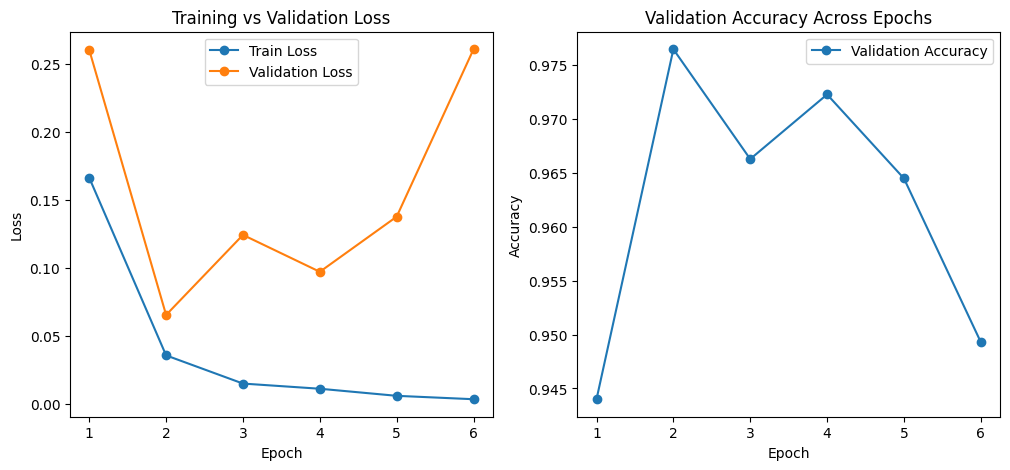

In [79]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6]

train_loss = [0.1664,0.0359,0.0152,0.0114,0.0062,0.0037]
val_loss   = [0.2603,0.0656,0.1244,0.0973,0.1378,0.2608]
val_acc    = [0.9440,0.9765,0.9663,0.9723,0.9645,0.9493]

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Across Epochs")
plt.legend()

plt.show()

## Audio Model
Step A: Extract Multi-Segment Audio Embeddings (Low RAM)

This cell extracts **Wav2Vec2 embeddings** from each audio file using multiple short segments.

What it does:
- Loads audio metadata and filters valid audio files
- Splits each audio into `N_SEG` segments (each `SEG_LEN_SEC` seconds)
- Passes each segment through pretrained **Wav2Vec2**
- Averages hidden states to obtain a fixed-size embedding
- Saves embeddings as `.npy` files per segment

Output:
- Multiple embedding files per video (e.g., `videoID__seg00.npy`)
- Stored inside `audio_embeddings_multiseg/`

These embeddings are later used for training the audio deepfake detection model.


In [67]:
# STEP A: extract multi-seg embeddings (low RAM)
!pip install -q transformers torchaudio numpy

import os, math, numpy as np, pandas as pd, torch, torchaudio
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from tqdm import tqdm

AUDIO_META = "/content/drive/MyDrive/multimodal-deepfake/data/fakeavceleb_audio_metadata.csv"
OUT_ROOT = "/content/drive/MyDrive/multimodal-deepfake/audio_embeddings_multiseg"
SEG_LEN_SEC = 2.0   # length of each segment in seconds
N_SEG = 4           # number of segments per audio (start/quarter/threequarter/end) OR use sliding below
MAX_LEN_SEC = SEG_LEN_SEC
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

os.makedirs(OUT_ROOT, exist_ok=True)
meta = pd.read_csv(AUDIO_META)
meta = meta[meta['audio_exists']==1].reset_index(drop=True)
print("Audio files to process:", len(meta))

# load model + fe
fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(DEVICE)
model.eval()

def get_segment_positions(total_len_s, seg_len_s, n_seg):
    # choose n_seg positions evenly (centered) across audio
    if total_len_s <= seg_len_s:
        return [0.0]
    positions = []
    if n_seg==1:
        positions = [ (total_len_s - seg_len_s)/2.0 ]
    else:
        # place centers evenly
        step = (total_len_s - seg_len_s) / float(max(1, n_seg-1))
        for i in range(n_seg):
            start = i * step
            positions.append(start)
    return positions

def load_audio_as_np(path):
    wav, sr = torchaudio.load(path)  # (channels, samples)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    wav = wav.squeeze(0).numpy().astype(np.float32)
    return wav, sr

def extract_and_save_embeddings():
    for _, r in tqdm(meta.iterrows(), total=len(meta), desc="Multi-seg embed"):
        cat = r['category']; vid = r['video_id']; path = r['audio_path']
        if not os.path.exists(path) or path=="":
            continue
        out_dir = os.path.join(OUT_ROOT, cat)
        os.makedirs(out_dir, exist_ok=True)

        # load audio once
        wav, sr = load_audio_as_np(path)
        # resample if needed
        if sr != 16000:
            wav = torchaudio.functional.resample(torch.tensor(wav), orig_freq=sr, new_freq=16000).numpy()
            sr = 16000
        total_len_s = len(wav) / float(sr)
        positions = get_segment_positions(total_len_s, SEG_LEN_SEC, N_SEG)
        for idx, start_s in enumerate(positions):
            start_sample = int(start_s * sr)
            end_sample = start_sample + int(SEG_LEN_SEC * sr)
            if end_sample > len(wav):
                # pad if necessary
                seg = np.pad(wav[start_sample:], (0, end_sample - len(wav)), mode='constant')
            else:
                seg = wav[start_sample:end_sample]
            # ensure shape
            seg = seg.astype(np.float32)
            # feature-extractor input is raw 1D array
            with torch.no_grad():
                inputs = fe(seg, sampling_rate=sr, return_tensors="pt", padding=True)
                iv = inputs["input_values"].to(DEVICE)
                out = model(iv)
                emb = out.last_hidden_state.squeeze(0).mean(dim=0).cpu().numpy()  # (hidden_dim,)
            out_path = os.path.join(out_dir, f"{vid}__seg{idx:02d}.npy")
            np.save(out_path, emb)
    print("Saved multi-seg embeddings to:", OUT_ROOT)

extract_and_save_embeddings()

Device: cpu


OSError: [Errno 30] Read-only file system: '/content'

In [ ]:
# STEP B: train classifier on multi-seg embeddings and aggregate per video
!pip install -q scikit-learn joblib

import os, glob, numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import joblib

EMB_ROOT = "/content/drive/MyDrive/multimodal-deepfake/audio_embeddings_multiseg"
META_CSV = "/content/drive/MyDrive/multimodal-deepfake/data/fakeavceleb_audio_metadata.csv"
OUT_MODEL = "/content/drive/MyDrive/multimodal-deepfake/models/audio_logreg_multiseg.joblib"
OUT_SCORES = "/content/drive/MyDrive/multimodal-deepfake/models/audio_scores_multiseg.csv"

# load metadata
meta = pd.read_csv(META_CSV)
meta = meta[meta['audio_exists']==1].reset_index(drop=True)

# collect per-segment embeddings with video mapping
X = []
Y = []
video_map = {}  # video -> list of row indices
meta_ids = []   # list of (cat, vid) in order of segments

for _, r in meta.iterrows():
    cat = r['category']; vid = r['video_id']; label = int(r['label'])
    pattern = os.path.join(EMB_ROOT, cat, f"{vid}__seg*.npy")
    seg_files = sorted(glob.glob(pattern))
    if len(seg_files)==0:
        continue
    vid_indices = []
    for f in seg_files:
        emb = np.load(f)
        idx = len(X)
        X.append(emb)
        Y.append(label)
        meta_ids.append((cat, vid))
        vid_indices.append(idx)
    video_map[(cat, vid)] = vid_indices

if len(X)==0:
    raise SystemExit("No segment embeddings found. Run extraction step.")

X = np.stack(X)
Y = np.array(Y)
print("Total segment samples:", X.shape)

# split by video (video-level split)
videos = list(video_map.keys())
labels_per_video = [ int(meta[(meta['category']==cat)&(meta['video_id']==vid)]['label'].values[0]) for cat,vid in videos ]
train_v, val_v = train_test_split(videos, test_size=0.15, stratify=labels_per_video, random_state=42)

train_idx = []
val_idx = []
for vid, idxs in video_map.items():
    if vid in train_v:
        train_idx += idxs
    else:
        val_idx += idxs

X_train, y_train = X[train_idx], Y[train_idx]
X_val, y_val = X[val_idx], Y[val_idx]
print("Segments train/val:", X_train.shape[0], X_val.shape[0])

# train classifier on segment-level
clf = LogisticRegression(class_weight='balanced', max_iter=2000)
clf.fit(X_train, y_train)

# evaluate per-segment (optional)
seg_probs = clf.predict_proba(X_val)[:,1]
seg_preds = (seg_probs>=0.5).astype(int)
try:
    seg_auc = roc_auc_score(y_val, seg_probs) if len(set(y_val))>1 else float('nan')
except:
    seg_auc = float('nan')
print("Segment-level AUC:", seg_auc)

# aggregate per-video: mean of segment probs
video_rows = []
for (cat, vid), idxs in video_map.items():
    seg_embs = X[idxs]
    probs = clf.predict_proba(seg_embs)[:,1]
    mean_prob = float(probs.mean())
    true_label = int(meta[(meta['category']==cat)&(meta['video_id']==vid)]['label'].values[0])
    video_rows.append({"category":cat, "video_id":vid, "true_label":true_label, "prob_fake":mean_prob, "n_segments": len(probs)})

vdf = pd.DataFrame(video_rows)
# evaluation on available videos
y_true = vdf['true_label'].values
y_prob = vdf['prob_fake'].values
y_pred = (y_prob>=0.5).astype(int)
auc = roc_auc_score(y_true, y_prob) if len(set(y_true))>1 else float('nan')
print("Video-level ROC AUC:", auc)
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

vdf.to_csv(OUT_SCORES, index=False)
joblib.dump(clf, OUT_MODEL)
print("Saved audio multiseg scores to:", OUT_SCORES, " and model to:", OUT_MODEL)

Total segment samples: (80, 768)
Segments train/val: 68 12
Segment-level AUC: 0.875
Video-level ROC AUC: 0.9866666666666667
Confusion matrix:
 [[ 5  0]
 [ 1 14]]
              precision    recall  f1-score   support

           0     0.8333    1.0000    0.9091         5
           1     1.0000    0.9333    0.9655        15

    accuracy                         0.9500        20
   macro avg     0.9167    0.9667    0.9373        20
weighted avg     0.9583    0.9500    0.9514        20

Saved audio multiseg scores to: /content/drive/MyDrive/multimodal-deepfake/models/audio_scores_multiseg.csv  and model to: /content/drive/MyDrive/multimodal-deepfake/models/audio_logreg_multiseg.joblib


## Final Audio Model Results

This cell evaluates the final per-video predictions from the audio model.

It:
- Loads `audio_scores_multiseg.csv`
- Computes Accuracy and ROC-AUC
- Displays the Confusion Matrix
- Prints Precision, Recall, and F1-score

This provides the final performance summary of the audio deepfake detector before multimodal fusion.

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Load your AUDIO per-video scores
df = pd.read_csv("/content/drive/MyDrive/multimodal-deepfake/models/audio_scores_multiseg.csv")

# True labels and predicted probabilities
y_true = df["true_label"].values
y_prob = df["prob_fake"].values
y_pred = (y_prob >= 0.5).astype(int)

# Basic counts
total = len(df)
num_fake = sum(y_true)
num_real = total - num_fake

correct = (y_pred == y_true).sum()
accuracy = correct / total

cm = confusion_matrix(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print("========== AUDIO MODEL FINAL RESULTS ==========")
print(f"Total Videos Evaluated: {total}")
print(f"Real Videos: {num_real}")
print(f"Fake Videos: {num_fake}")
print()
print(f"Correctly Classified Videos: {correct}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"ROC AUC: {auc:.3f}")
print()

print("Confusion Matrix:")
print(cm)
print()

print("Interpretation:")
print(f"- True Negatives (Real correctly detected): {cm[0][0]}")
print(f"- False Positives (Real predicted as Fake): {cm[0][1]}")
print(f"- False Negatives (Fake predicted as Real): {cm[1][0]}")
print(f"- True Positives (Fake correctly detected): {cm[1][1]}")
print()

print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

========== AUDIO MODEL FINAL RESULTS ==========
Total Videos Evaluated: 20
Real Videos: 5
Fake Videos: 15

Correctly Classified Videos: 19
Accuracy: 95.00%
ROC AUC: 0.987

Confusion Matrix:
[[ 5  0]
 [ 1 14]]

Interpretation:
- True Negatives (Real correctly detected): 5
- False Positives (Real predicted as Fake): 0
- False Negatives (Fake predicted as Real): 1
- True Positives (Fake correctly detected): 14

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.83      1.00      0.91         5
        Fake       1.00      0.93      0.97        15

    accuracy                           0.95        20
   macro avg       0.92      0.97      0.94        20
weighted avg       0.96      0.95      0.95        20



In [ ]:
# Create metadata file for training by scanning processed_perframe folders
import os, pandas as pd, glob

PERFRAME_ROOT = "/content/drive/MyDrive/multimodal-deepfake/processed_perframe"
OUT_META = "/content/drive/MyDrive/multimodal-deepfake/data/fakeavceleb_metadata_150.csv"

rows = []
if not os.path.exists(PERFRAME_ROOT):
    raise SystemExit(f"Processed per-frame root not found: {PERFRAME_ROOT}")

for cat in sorted(os.listdir(PERFRAME_ROOT)):
    cat_path = os.path.join(PERFRAME_ROOT, cat)
    if not os.path.isdir(cat_path):
        continue
    for vid in sorted(os.listdir(cat_path)):
        vid_path = os.path.join(cat_path, vid)
        if not os.path.isdir(vid_path):
            continue
        # count frames to ensure it's not an empty folder
        frame_files = glob.glob(os.path.join(vid_path, "frame_*.jpg"))
        if len(frame_files) == 0:
            # skip empty / placeholder dirs
            continue
        # infer labels from category folder name if possible (adjust if your naming differs)
        cat_lower = cat.lower()
        face_label = "fake" if "fakevideo" in cat_lower else "real"
        audio_label = "fake" if "fakeaudio" in cat_lower else "real"
        rows.append({
            "category_folder": cat,
            "relative_path": vid,
            "face_label": face_label,
            "audio_label": audio_label,
            "n_frames": len(frame_files)
        })

df = pd.DataFrame(rows).sort_values(["category_folder","relative_path"]).reset_index(drop=True)
df.to_csv(OUT_META, index=False)
print("Wrote metadata for", len(df), "videos to:", OUT_META)
print("\nPreview (first 10 rows):")
print(df.head(10).to_string(index=False))
print("\nIf this looks correct, set META_CSV in the training script to this path and run training.")

Wrote metadata for 20 videos to: /content/drive/MyDrive/multimodal-deepfake/data/fakeavceleb_metadata_150.csv

Preview (first 10 rows):
    category_folder        relative_path face_label audio_label  n_frames
FakeVideo-FakeAudio              African       fake        fake        55
FakeVideo-FakeAudio         Asian (East)       fake        fake        23
FakeVideo-FakeAudio        Asian (South)       fake        fake        35
FakeVideo-FakeAudio Caucasian (American)       fake        fake        24
FakeVideo-FakeAudio Caucasian (European)       fake        fake        24
FakeVideo-RealAudio              African       fake        real        31
FakeVideo-RealAudio         Asian (East)       fake        real        19
FakeVideo-RealAudio        Asian (South)       fake        real        23
FakeVideo-RealAudio Caucasian (American)       fake        real        22
FakeVideo-RealAudio Caucasian (European)       fake        real        20

If this looks correct, set META_CSV in the traini

In [ ]:
# --- Scaled EfficientNet training (per-frame fine-tune) ---
# Requirements: timm, torch, torchvision
!pip install -q timm

import os, glob, random, math, pandas as pd, numpy as np, time
from PIL import Image
from tqdm import tqdm
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# ----------------- CONFIG - EDIT THESE -----------------
META_CSV = "/content/drive/MyDrive/multimodal-deepfake/data/fakeavceleb_metadata_150.csv"  # updated metadata listing all 150 vids
PERFRAME_ROOT = "/content/drive/MyDrive/multimodal-deepfake/processed_perframe"  # contains <cat>/<video_id>/frame_*.jpg
MODEL_OUT = "/content/drive/MyDrive/multimodal-deepfake/models/visual_effnet_b0_big.pth"
SCORES_OUT = "/content/drive/MyDrive/multimodal-deepfake/models/visual_scores_perframe_big.csv"
LOG_CSV = "/content/drive/MyDrive/multimodal-deepfake/logs/visual_train_log.csv"

IMG_SIZE = 224
BATCH_SIZE = 32           # reduce if OOM
EPOCHS = 12
LR = 2e-4
WEIGHT_DECAY = 1e-4
SEED = 42
NUM_WORKERS = 4           # try 4 on Colab; 0 if CPU
USE_AMP = torch.cuda.is_available()  # use mixed precision if GPU available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# -----------------------------------------------------

print("Device:", DEVICE)

# reproducibility
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Build dataset list by reading perframe folders and metadata ---
meta = pd.read_csv(META_CSV)
# Expect meta to have columns: category_folder, relative_path (video_id), face_label (fake/real)
entries = []
for _, r in meta.iterrows():
    cat = r['category_folder']; vid = r['relative_path']
    folder = os.path.join(PERFRAME_ROOT, cat, vid)
    if os.path.isdir(folder):
        imgs = sorted(glob.glob(os.path.join(folder, "frame_*.jpg")))
        label = 1 if r.get('face_label',"fake")=="fake" else 0
        for p in imgs:
            entries.append((p, label, cat, vid))
print("Total frames collected:", len(entries))

if len(entries) == 0:
    raise SystemExit("No per-frame images found — check PERFRAME_ROOT and META_CSV")

# split by video to avoid leakage
video_map = {}
for p,label,cat,vid in entries:
    video_map.setdefault((cat,vid), []).append((p,label))
video_keys = list(video_map.keys())
video_labels = [1 if meta[(meta['category_folder']==cat)&(meta['relative_path']==vid)]['face_label'].values[0]=="fake" else 0 for cat,vid in video_keys]

train_v, val_v = train_test_split(video_keys, test_size=0.15, random_state=SEED, stratify=video_labels)
train_entries = []
val_entries = []
for catvid, arr in video_map.items():
    if catvid in train_v:
        train_entries += arr
    else:
        val_entries += arr

print("Frames in train:", len(train_entries), "val:", len(val_entries), "videos train/val:", len(train_v), len(val_v))

# --- Dataset & transforms ---
train_tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1,0.1,0.1,0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class FrameDataset(Dataset):
    def __init__(self, entries, transform=None):
        self.entries = entries
        self.transform = transform
    def __len__(self): return len(self.entries)
    def __getitem__(self, idx):
        p,label = self.entries[idx][0], self.entries[idx][1]
        img = Image.open(p).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(FrameDataset(train_entries, transform=train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(FrameDataset(val_entries, transform=val_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# --- Model, optimizer, scheduler ---
model = timm.create_model('tf_efficientnet_b0', pretrained=True, num_classes=2)
model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_val_metric = -1.0
log_rows = []

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0; n=0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} train")
    for imgs, labels in pbar:
        imgs = imgs.to(DEVICE); labels = labels.to(DEVICE)
        optimizer.zero_grad()
        if USE_AMP:
            with torch.cuda.amp.autocast():
                out = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * imgs.size(0); n += imgs.size(0)
    scheduler.step()
    train_loss = running_loss / n if n>0 else 0.0

    # validation (frame-level metrics)
    model.eval()
    val_loss = 0.0; correct = 0; total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE); labels = labels.to(DEVICE)
            if USE_AMP:
                with torch.cuda.amp.autocast():
                    out = model(imgs)
                    loss = criterion(out, labels)
            else:
                out = model(imgs)
                loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds==labels).sum().item()
            total += imgs.size(0)
    val_acc = correct/total if total>0 else 0
    val_loss = val_loss / total if total>0 else 0

    # Save log
    log_rows.append({"epoch":epoch, "train_loss":train_loss, "val_loss":val_loss, "val_acc":val_acc})
    pd.DataFrame(log_rows).to_csv(LOG_CSV, index=False)

    print(f"Epoch {epoch}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    # save checkpoint periodically and best
    ckpt_path = MODEL_OUT.replace(".pth", f".epoch{epoch}.pth")
    torch.save(model.state_dict(), ckpt_path)
    if val_acc > best_val_metric:
        best_val_metric = val_acc
        torch.save(model.state_dict(), MODEL_OUT)
        print("Saved best model to", MODEL_OUT)

# ---------- Per-video aggregation ----------
print("Aggregating per-video scores...")
model.eval()
video_results = []
with torch.no_grad():
    for (cat,vid), frames in video_map.items():
        folder = os.path.join(PERFRAME_ROOT, cat, vid)
        imgs = sorted(glob.glob(os.path.join(folder, "frame_*.jpg")))
        if len(imgs)==0: continue
        probs=[]
        for p in imgs:
            img = Image.open(p).convert('RGB')
            inp = val_tf(img).unsqueeze(0).to(DEVICE)
            out = model(inp)
            prob = torch.softmax(out, dim=1)[0,1].item()
            probs.append(prob)
        mean_prob = float(np.mean(probs))
        true_label = 1 if meta[(meta['category_folder']==cat)&(meta['relative_path']==vid)]['face_label'].values[0]=="fake" else 0
        video_results.append({"video_id":vid, "category":cat, "true_label":true_label, "prob_fake":mean_prob, "n_frames":len(probs)})

vdf = pd.DataFrame(video_results)
vdf.to_csv(SCORES_OUT, index=False)
print("Saved per-video visual scores to:", SCORES_OUT)

/tmp/ipykernel_28939/2694722415.py:110: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Device: cpu
Total frames collected: 286
Frames in train: 261 val: 25 videos train/val: 17 3


Epoch 1 train:   0%|          | 0/9 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1 train: 100%|██████████| 9/9 [00:23<00:00,  2.63s/it]


Epoch 1/12  train_loss=0.5533  val_loss=1.6792  val_acc=0.4400
Saved best model to /content/drive/MyDrive/multimodal-deepfake/models/visual_effnet_b0_big.pth


Epoch 2 train: 100%|██████████| 9/9 [00:23<00:00,  2.57s/it]


...

Epoch 10/12  train_loss=0.0494  val_loss=0.1056  val_acc=0.9600


Epoch 11 train: 100%|██████████| 9/9 [00:22<00:00,  2.45s/it]


Epoch 11/12  train_loss=0.0185  val_loss=0.1441  val_acc=0.9600


Epoch 12 train: 100%|██████████| 9/9 [00:21<00:00,  2.42s/it]


Epoch 12/12  train_loss=0.0169  val_loss=0.1974  val_acc=0.9600
Aggregating per-video scores...
Saved per-video visual scores to: /content/drive/MyDrive/multimodal-deepfake/models/visual_scores_perframe_big.csv


In [ ]:
# Aggregate frame-level probs into per-video scores
import os, glob, numpy as np, pandas as pd
from PIL import Image
import torch
import torchvision.transforms as T

MODEL_PATH = "/content/drive/MyDrive/multimodal-deepfake/models/visual_effnet_b0_big.pth"
PERFRAME_ROOT = "/content/drive/MyDrive/multimodal-deepfake/processed_perframe"
META_CSV = "/content/drive/MyDrive/multimodal-deepfake/data/fakeavceleb_metadata_150.csv"
OUT_SCORES = "/content/drive/MyDrive/multimodal-deepfake/models/visual_scores_perframe_big.csv"

# load model same as training (timm)
import timm, torch.nn.functional as F
model = timm.create_model('tf_efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model.eval()

# val transform (same as training val)
val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

meta = pd.read_csv(META_CSV)
video_rows = []
for _, r in meta.iterrows():
    cat = r['category_folder']; vid = r['relative_path']
    folder = os.path.join(PERFRAME_ROOT, cat, vid)
    imgs = sorted(glob.glob(os.path.join(folder, "frame_*.jpg")))
    if len(imgs) == 0:
        continue
    probs = []
    for p in imgs:
        img = Image.open(p).convert('RGB')
        inp = val_tf(img).unsqueeze(0)
        with torch.no_grad():
            out = model(inp)
            prob = F.softmax(out, dim=1)[0,1].item()
        probs.append(prob)
    video_rows.append({"category":cat, "video_id":vid, "true_label": 1 if r['face_label']=="fake" else 0,
                       "prob_fake": float(np.mean(probs)), "n_frames": len(probs)})

pd.DataFrame(video_rows).to_csv(OUT_SCORES, index=False)
print("Saved per-video scores to:", OUT_SCORES)

Saved per-video scores to: /content/drive/MyDrive/multimodal-deepfake/models/visual_scores_perframe_big.csv


In [ ]:
# Clean summary printer (video-level)
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

df = pd.read_csv("/content/drive/MyDrive/multimodal-deepfake/models/visual_scores_perframe_big.csv")
y_true = df["true_label"].values
y_prob = df["prob_fake"].values
y_pred = (y_prob >= 0.5).astype(int)

total = len(df); num_fake = int(y_true.sum()); num_real = total - num_fake
correct = int((y_pred == y_true).sum())
accuracy = correct / total
cm = confusion_matrix(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print("========== VISUAL MODEL FINAL RESULTS ==========")
print(f"Total Videos Evaluated: {total}")
print(f"Real Videos: {num_real}")
print(f"Fake Videos: {num_fake}\n")
print(f"Correctly Classified Videos: {correct}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"ROC AUC: {auc:.3f}\n")
print("Confusion Matrix:")
print(cm, "\n")
print("Interpretation:")
print(f"- True Negatives (Real correctly detected): {cm[0][0]}")
print(f"- False Positives (Real predicted as Fake): {cm[0][1]}")
print(f"- False Negatives (Fake predicted as Real): {cm[1][0]}")
print(f"- True Positives (Fake correctly detected): {cm[1][1]}\n")
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Real','Fake']))

========== VISUAL MODEL FINAL RESULTS ==========
Total Videos Evaluated: 20
Real Videos: 10
Fake Videos: 10

Correctly Classified Videos: 18
Accuracy: 90.00%
ROC AUC: 0.970

Confusion Matrix:
[[ 8  2]
 [ 0 10]] 

Interpretation:
- True Negatives (Real correctly detected): 8
- False Positives (Real predicted as Fake): 2
- False Negatives (Fake predicted as Real): 0
- True Positives (Fake correctly detected): 10

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.80      0.89        10
        Fake       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20

